### 1. Import Libraries & Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff

import xgboost as xgb
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

import joblib
import warnings
warnings.filterwarnings("ignore")


!pip install shap -q
import shap

print("Libraries loaded successfully.")

Libraries loaded successfully.


### 2. Load and Inspect Data

In [12]:
print("Loading train and test data...")
train_raw = pd.read_csv('/content/train (1).csv', index_col=0)
test_raw = pd.read_csv('/content/test.csv', index_col=0)

print(f"Raw train data shape: {train_raw.shape}")
print(f"Raw test data shape: {test_raw.shape}")
display(train_raw.head(3))

Loading train and test data...
Raw train data shape: (103904, 24)
Raw test data shape: (25976, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied


### 3. Target Definition

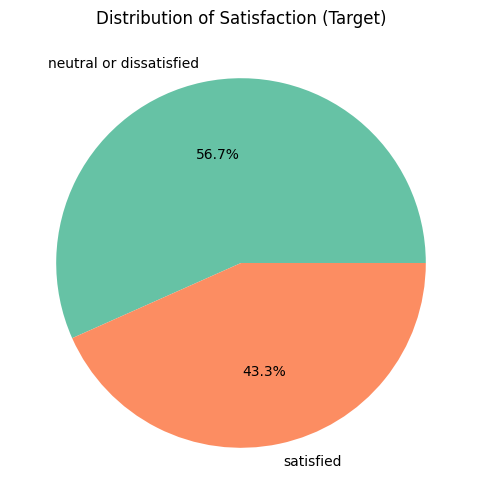

In [13]:
plt.figure(figsize=(6, 6))
plt.pie(train_raw['satisfaction'].value_counts(),
        labels=train_raw['satisfaction'].value_counts().index,
        autopct='%1.1f%%', colors=sns.color_palette("Set2"))
plt.title('Distribution of Satisfaction (Target)')
plt.show()

### 4. Data Preprocessing & Baseline Model Evaluation
Here, we manually preprocess the data (splitting first to prevent data leakage during imputation) and evaluate a baseline XGBoost model on all features.

In [14]:
# 1. Drop useless columns
cols_to_drop = ['Unnamed: 0', 'id']
train_clean = train_raw.drop(columns=[c for c in cols_to_drop if c in train_raw.columns])
test_clean = test_raw.drop(columns=[c for c in cols_to_drop if c in test_raw.columns])

# 2. Separate Target Variable and Features
y_train = train_clean['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
X_train = train_clean.drop(columns=['satisfaction'])

y_test = test_clean['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
X_test = test_clean.drop(columns=['satisfaction'])

# 3. Handle Missing Values (Arrival Delay) using TRAIN set median
median_delay = X_train['Arrival Delay in Minutes'].median()
X_train['Arrival Delay in Minutes'].fillna(median_delay, inplace=True)
X_test['Arrival Delay in Minutes'].fillna(median_delay, inplace=True)

# 4. Safe Encoding for Baseline & SHAP
# Tree models handle ordinal encoding well. We use OrdinalEncoder for safe mapping of unseen categories.
categorical_cols = X_train.select_dtypes(include=['object']).columns

X_train_base = X_train.copy()
X_test_base = X_test.copy()

from sklearn.preprocessing import OrdinalEncoder
ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_base[categorical_cols] = ord_enc.fit_transform(X_train_base[categorical_cols])
X_test_base[categorical_cols] = ord_enc.transform(X_test_base[categorical_cols])

# 5. Train Baseline Model
print("Training Baseline XGBoost Model on ALL features...")
base_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
base_xgb.fit(X_train_base, y_train)

# 6. Evaluate Baseline on explicitly provided Test Set
base_preds = base_xgb.predict(X_test_base)
print("\n--- Baseline Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, base_preds):.4f}")
print(f"F1-Macro: {f1_score(y_test, base_preds, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, base_preds))

Training Baseline XGBoost Model on ALL features...

--- Baseline Model Performance ---
Accuracy: 0.9633
F1-Macro: 0.9626

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     14573
           1       0.97      0.95      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



#### 4.1 SHAP Value Analysis for Feature Selection

Calculating SHAP values...


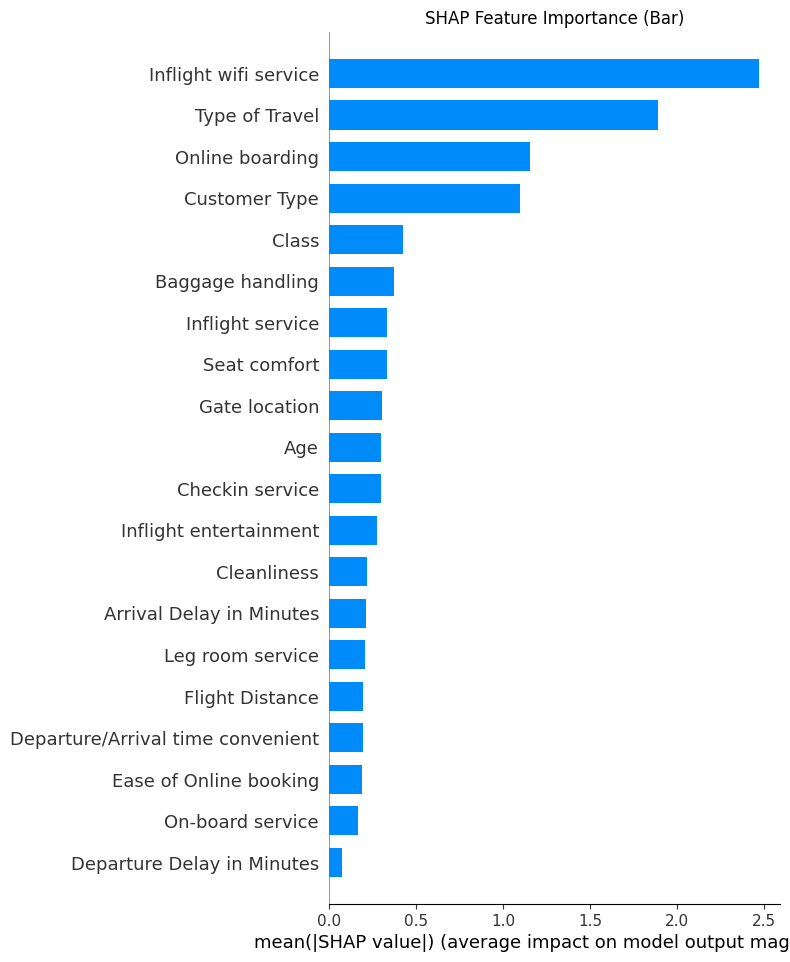

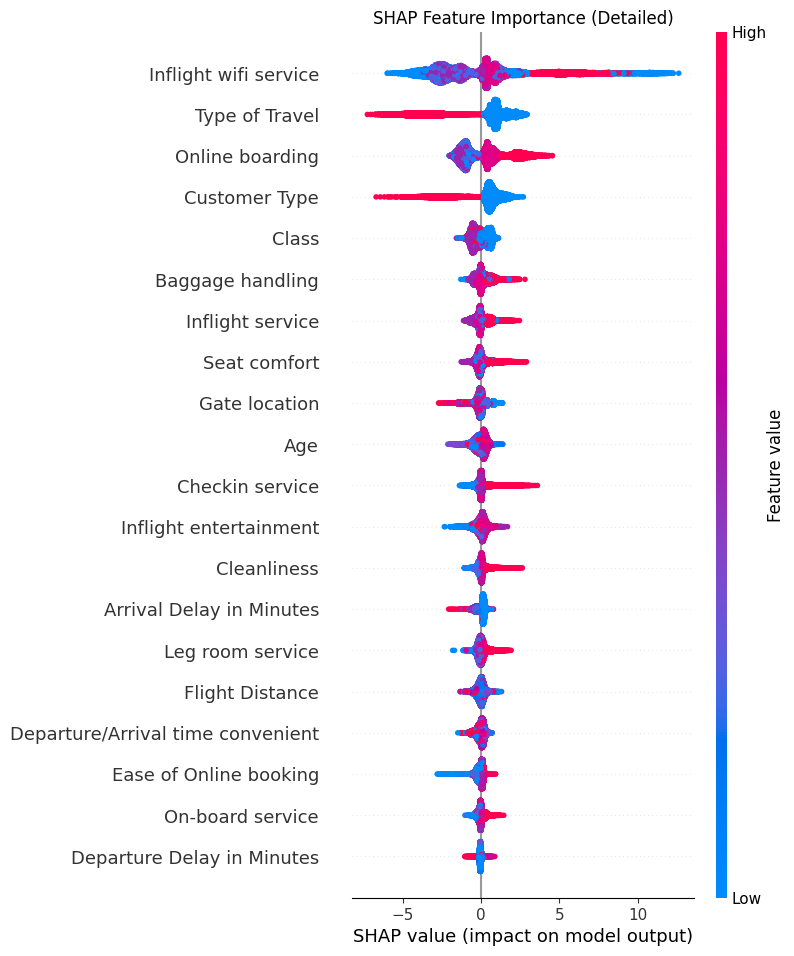

In [15]:
print("Calculating SHAP values on Training Data to prevent leakage...")
# Calculate SHAP values strictly on the training set.
# We use a sample of 10,000 to keep the computation fast.
X_train_sample = X_train_base.sample(n=10000, random_state=42)

explainer = shap.TreeExplainer(base_xgb)
shap_values = explainer.shap_values(X_train_sample)

# Plot SHAP summary
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Bar)")
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_train_sample, show=False)
plt.title("SHAP Feature Importance (Detailed)")
plt.show()

In [18]:
### 5. Advanced Feature Selection
#Based on SHAP and XGBoost built-in importance, we select the top features to build a robust and less noisy model, aligning with the SVM pipeline's minimalist approach.

Evaluating optimal number of features based on SHAP ranking...


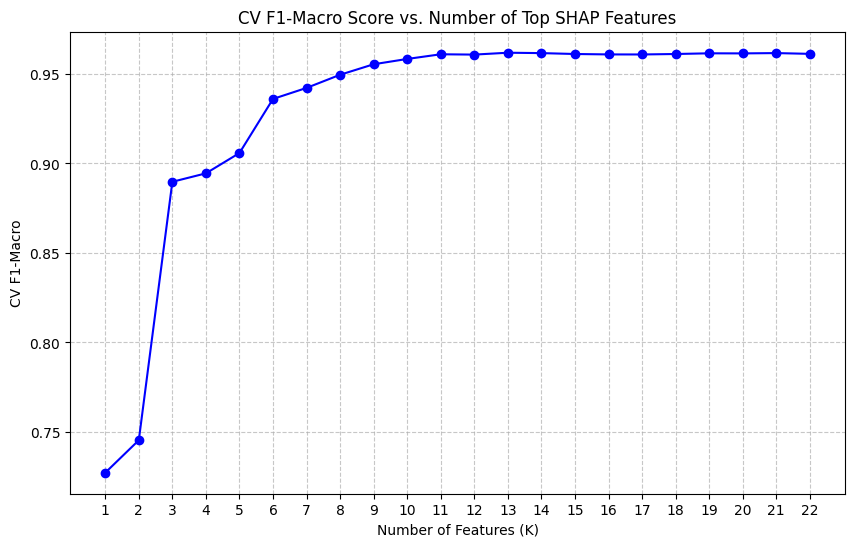

Optimal number of features: 13
Maximum CV F1-Macro: 0.9619

Top 13 Selected Features:
- Inflight wifi service
- Type of Travel
- Online boarding
- Customer Type
- Class
- Baggage handling
- Inflight service
- Seat comfort
- Gate location
- Age
- Checkin service
- Inflight entertainment
- Cleanliness


In [24]:
from sklearn.model_selection import cross_val_score

# 1. Extract features ordered by SHAP importance
shap_sum = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame([X_train_sample.columns.tolist(), shap_sum.tolist()]).T
importance_df.columns = ['column_name', 'shap_importance']
importance_df = importance_df.sort_values('shap_importance', ascending=False)
ranked_features = importance_df['column_name'].tolist()

# 2. Evaluate optimal number of features (N)
cv_scores = []
k_values = range(1, len(ranked_features) + 1)

print("Evaluating optimal number of features based on SHAP ranking...")
for k in k_values:
    selected_k = ranked_features[:k]
    X_subset = X_train_base[selected_k]

    # Use a fast baseline XGB for evaluation
    temp_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')

    # Cross-validation
    scores = cross_val_score(temp_xgb, X_subset, y_train, cv=3, scoring='f1_macro', n_jobs=-1)
    cv_scores.append(scores.mean())

# 3. Plot the performance curve
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='-', color='b')
plt.title('CV F1-Macro Score vs. Number of Top SHAP Features')
plt.xlabel('Number of Features (K)')
plt.ylabel('CV F1-Macro')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 4. Find the optimal K (max F1 score)
optimal_k = k_values[np.argmax(cv_scores)]
max_f1 = np.max(cv_scores)

print(f"Optimal number of features: {optimal_k}")
print(f"Maximum CV F1-Macro: {max_f1:.4f}")

# 5. Set TOP_N to optimal_k and select features
TOP_N = optimal_k
selected_features = ranked_features[:TOP_N]

print(f"\nTop {TOP_N} Selected Features:")
for f in selected_features:
    print(f"- {f}")

In [20]:
### 6. Scikit-Learn Pipeline & Hyperparameter Tuning
#ow we create a reproducible pipeline. We will use `OneHotEncoder` for categoricals (standard for mixed pipelines) and tune the XGBoost model using `GridSearchCV` focusing on `f1_macro`.

In [21]:
# Prepare final data with selected features using the ORIGINAL raw features (before manual imputation)
X_train_pipe = X_train[selected_features]
X_test_pipe = X_test[selected_features]
y_train_pipe = y_train
y_test_pipe = y_test

# Re-evaluate feature types for the pipeline
final_cat_features = [f for f in selected_features if f in categorical_cols]
final_num_features = [f for f in selected_features if f not in categorical_cols]

# Define Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                # Use OneHotEncoder for the final pipeline to be robust
                ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]),
            final_cat_features
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            final_num_features
        )
    ]
)

# Define the full Pipeline
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("xgb", xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

#### 6.1 RandomizedSearchCV

In [22]:
from sklearn.model_selection import RandomizedSearchCV

# Define a broader parameter distribution for RandomizedSearchCV
param_dist = {
    'xgb__n_estimators': [100, 200, 300, 400],
    'xgb__max_depth': [3, 5, 7, 9],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__min_child_weight': [1, 3, 5]
}

# Stratified K-Fold for robust evaluation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=20, # Number of random parameter combinations to try
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("Starting Randomized Search...")
random_search.fit(X_train_pipe, y_train_pipe)

print("\nBest parameters:", random_search.best_params_)
print("Best CV f1_macro:", random_search.best_score_)

Starting Grid Search...
Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 200, 'xgb__subsample': 1.0}
Best CV f1_macro: 0.9586002982264858


### 7. Evaluation & Export Pipeline for Ensemble

--- Tuned Pipeline Performance ---
Test Accuracy: 0.9601940252540807
Test F1 Macro: 0.9594614158394512

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96     14573
           1       0.97      0.94      0.95     11403

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



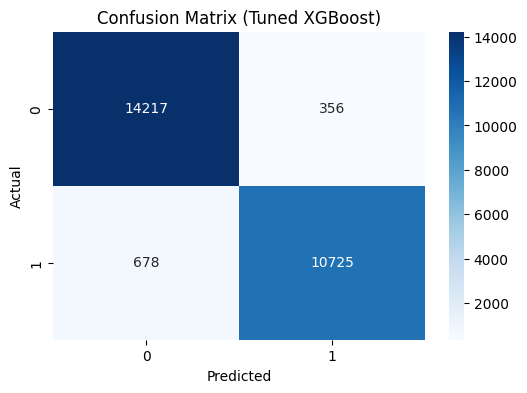

Pipeline successfully saved as 'xgb_pipeline.pkl' for ensemble.


In [23]:
best_model = random_search.best_estimator_

# Evaluate on Test Set
y_pred = best_model.predict(X_test_pipe)

print("--- Tuned Pipeline Performance ---")
print("Test Accuracy:", accuracy_score(y_test_pipe, y_pred))
print("Test F1 Macro:", f1_score(y_test_pipe, y_pred, average="macro"))
print("\nClassification Report:\n")
print(classification_report(y_test_pipe, y_pred))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test_pipe, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Tuned XGBoost)")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save the Pipeline for Ensemble
joblib.dump(best_model, "xgb_pipeline.pkl")
print("Pipeline successfully saved as 'xgb_pipeline.pkl' for ensemble.")